## __Aprendizaje no supervisado__

__Profesor__: Anthony D. Cho

__Ayudante__: Luis Oliveros

__Asunto__: t-SNE

***

## Librerias

In [2]:
pip install plotly

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.8 MB 8.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.8 MB 12.2 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.8 MB 13.6 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 12.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------

In [3]:
from time import time
from itertools import product
from tqdm import tqdm
from pandas import read_csv, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

__Dataset:__

Estos datos están referenciados en [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/94/spambase) que contiene 4601 emails en que algunos son spams y otras no lo son.

<center>
<img src='https://s.ipvm.com/uploads/embedded_image/f8f6a883b912309b2df1f51221a8fe8f9156267a29dc0fa03246b04e812d13d2/1b6fbf8f-dcc5-4f91-b208-b6d27b6d33c0.gif' width=800>
</center>

In [4]:
## Carga de datos
dataset = read_csv('https://raw.githubusercontent.com/adoc-box/Datasets/main/spambase.csv')

## Mostrar las primeras 5 observaciones
dataset.head()

,make,address,all,3d,our,over,remove,internet,order,mail,...,;,(,[,!,$,#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [5]:
## Extracción de información del objeto dataset
X, y = dataset.drop(columns=['Class']), dataset['Class']

## Dimensiones
print('(shape) X: {}. y: {}'.format(X.shape, y.shape))

(shape) X: (4601, 57). y: (4601,)


In [6]:
## Mostrar las primeras 5 observaciones
X.head()

,make,address,all,3d,our,over,remove,internet,order,mail,...,conference,;,(,[,!,$,#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [7]:
## Mostrar la cantidad de observaciones por etiquetas
y.value_counts(sort=False)

Class
1    1813
0    2788
Name: count, dtype: int64

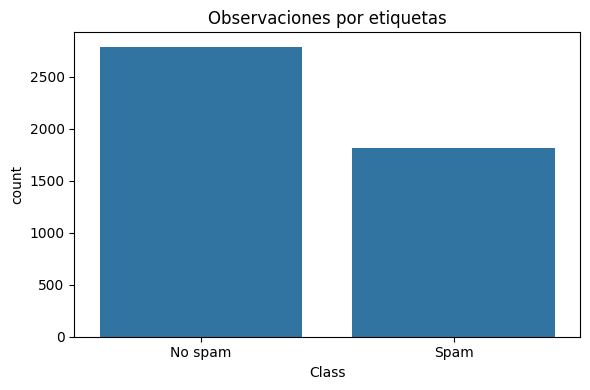

In [8]:
count_labels = y.value_counts(sort=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=count_labels.index, y=count_labels)
plt.xticks(ticks=count_labels.index, labels=['Spam', 'No spam'])
plt.title('Observaciones por etiquetas')
plt.tight_layout()
plt.show()

#### Escalado de los datos

In [9]:
## Escalamos los datos
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
print('(shape) X escalado: {}'.format(X_scaled.shape))

(shape) X escalado: (4601, 57)


## Modelo t-SNE

Existen múltiples hiperparámetros para el modelo t-SNE:<br>

```{python}
    tsne_model = TSNE(n_components=2, 
                      perplexity=30.0, 
                      max_iter=1000, 
                      learning_rate=10,
                      random_state=None)
```

| Hiperparámetros | Descripción |
|-----------------|-------------|
| __n_components__  | número de componentes (por defecto, 2).|
| __perplexity__ | está relacionada a la vecinda de cada punto. Se recomienda en valores [5, 50] (por defecto, 30)|
| __max_iter__ | número máximo de iteraciones usado en la optimización. Generalmente es mayor que 250 (por defecto, 1000) | 
| __learning_rate__ | es la tasa de aprendizaje para el ajuste del modelo. Se recomienda valores [10.0, 1000.0] (por defecto, 10) |
| __random_state__ | semilla de aleatoriedad para inicialización de los puntos en el espacio reducido.|


Para ajuste y transformación de los datos se emplean las siguientes funciones:

* __fit(X)__ : entrena el modelo usando un conjunto de datos.

* __fit_transform(X)__: entrena el modelo y transforma un conjunto de datos al espacio reducido.

## Caracteristicas del modelo entrenado
Una vez entrenado el modelo, existen nuevas funciones y características que podemos observar (atributos)<br>

<br>

| Atributos | Descripción |
|-----------|-------------|
| embedding_ | Almacena los datos transformados al espacio reducido. |
| kl_divergence_ | Valor de Kullback-Leibler divergence después de la optimization. |

## Reducción dimensional a 2D mediante t-SNE

In [10]:
start = time()

## Instancia del modelo
tsne_model = TSNE(n_components=2, 
                  perplexity=30, 
                  max_iter=1000, 
                  learning_rate=10,
                  verbose=1,
                  random_state=9001)

## Ajuste del modelo y transforma los datos al espacio reducido.
X_tsne = tsne_model.fit_transform(X_scaled)

timeUp = time()
print('Time spent[s]: {:.3f}'.format(timeUp -start))

## Imprimir la dimensiona de los datos transformados
print('(shape) X by t-SNE: {}'.format(X_tsne.shape))

## Mostrar el valor de KL-divergence 
print('KL-divergence: {}'.format(tsne_model.kl_divergence_))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4601 samples in 0.006s...
[t-SNE] Computed neighbors for 4601 samples in 6.248s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4601
[t-SNE] Computed conditional probabilities for sample 2000 / 4601
[t-SNE] Computed conditional probabilities for sample 3000 / 4601
[t-SNE] Computed conditional probabilities for sample 4000 / 4601
[t-SNE] Computed conditional probabilities for sample 4601 / 4601
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.672188
[t-SNE] KL divergence after 1000 iterations: 1.432153
Time spent[s]: 20.182
(shape) X by t-SNE: (4601, 2)
KL-divergence: 1.4321526288986206


In [11]:
DataFrame(X_tsne, columns=['Dim1', 'Dim2'])

,Dim1,Dim2
0,-17.657581,-3.352760
1,-7.167058,23.075550
2,-17.594887,34.115170
3,-15.950747,5.601037
4,-15.951040,5.600854
...,...,...
4596,1.386661,-2.562412
4597,-6.685918,-16.388777
4598,1.694402,-13.723519
4599,-5.103462,1.829035


#### Graficado de los datos transformados

In [ ]:
## Lista de colores
colors = sns.color_palette()

## Graficar los datos por clases. 
plt.figure(figsize=(8, 6))
for i in y.unique():
    mask = y == i
    pxs, pys = X_tsne[mask ,0], X_tsne[mask, 1]
    plt.scatter(pxs, pys, color=colors[i], 
                alpha=0.5, s=9, lw=2, 
                label=['No Spam', 'Spam'][i])
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(loc=[1.01, 0.5])
plt.tight_layout()
plt.show()


## ¿Funcionaría si se va optimizando en cascada los hiperparametros?

#### Variando el hiperpárametro: perplexity

In [ ]:
## Duración: 10 min aprox. en colab

## Lista de colores
colors = sns.color_palette()

## Lista de posible valores para el hiperparametro
lista_vals = [2, 5, 10, 30, 50, 75, 100, 125, 150, 200, 250, 300]

## Almacenador de resultados
resultados = {'perplexity': lista_vals, 
              'KL': []}

plt.figure(figsize=(10, 6))
for k, p in tqdm(list(enumerate(lista_vals))):

    ## Instancia del modelo
    tsne_model = TSNE(n_components=2, 
                    perplexity=p, 
                    max_iter=1000, 
                    learning_rate=10,
                    random_state=9001)

    ## Ajuste del modelo y transforma los datos al espacio reducido.
    X_tsne = tsne_model.fit_transform(X_scaled)

    ## Almacenar el valor de KL-divergence obtenido
    resultados['KL'].append( tsne_model.kl_divergence_ )

    plt.subplot(3, 4, k+1)

    for i in y.unique():
        mask = y == i
        pxs, pys = X_tsne[mask ,0], X_tsne[mask, 1]
        plt.scatter(pxs, pys, color=colors[i], 
                    alpha=0.5, s=9, lw=2, 
                    label=['No Spam', 'Spam'][i])
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.title(f'Perplexity: {p}')

plt.tight_layout()
plt.show()

In [ ]:
## Mostrar los resultados obtenidos
resultados = DataFrame(resultados)

plt.figure(figsize=(10, 3))
sns.pointplot(data=resultados, x='perplexity', y='KL')
plt.tight_layout()
plt.show()

#### Variando el hiperpárametro: la tasa de aprendizaje

In [ ]:
## Duración: 7 min aprox. en colab

## Lista de colores
colors = sns.color_palette()

## Lista de posible valores para el hiperparametro
lista_vals = [10, 20, 50, 75, 100, 150, 300, 500, 1000, 1500, 2000, 3000]

## Almacenador de resultados
resultados = {'lr': lista_vals, 
              'KL': []}

plt.figure(figsize=(10, 6))
for k, lr in tqdm(list(enumerate(lista_vals))):

    ## Instancia del modelo
    tsne_model = TSNE(n_components=2, 
                      perplexity=30, # <- Seleccionado. 
                      max_iter=1000,
                      learning_rate=lr,
                      random_state=9001)

    ## Ajuste del modelo y transforma los datos al espacio reducido.
    X_tsne = tsne_model.fit_transform(X_scaled)

    ## Almacenar el valor de KL-divergence obtenido
    resultados['KL'].append( tsne_model.kl_divergence_ )

    plt.subplot(3, 4, k+1)

    for i in y.unique():
        mask = y == i
        pxs, pys = X_tsne[mask ,0], X_tsne[mask, 1]
        plt.scatter(pxs, pys, color=colors[i], 
                    alpha=0.5, s=9, lw=2, 
                    label=['No Spam', 'Spam'][i])
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.title(f'lr: {lr}')

plt.tight_layout()
plt.show()

In [ ]:
## Mostrar los resultados obtenidos
resultados = DataFrame(resultados)

plt.figure(figsize=(10, 3))
sns.pointplot(data=resultados, x='lr', y='KL')
plt.tight_layout()
plt.show()

#### Variando el hiperpárametro: número de iteraciones

In [ ]:
## Duración: 40 min aprox. en colab

## Lista de colores
colors = sns.color_palette()

## Lista de posible valores para el hiperparametro
lista_vals = [250, 300, 350, 400, 450, 500, 750, 1000, 1250, 1500, 2000, 3000]

## Almacenador de resultados
resultados = {'n_iter': lista_vals, 
              'KL': []}

plt.figure(figsize=(10, 6))
for k, n_iter in tqdm(list(enumerate(lista_vals))):

    ## Instancia del modelo
    tsne_model = TSNE(n_components=2, 
                      perplexity=30, 
                      max_iter=n_iter,
                      learning_rate=500, # <- Seleccionado.
                      random_state=9001)

    ## Ajuste del modelo y transforma los datos al espacio reducido.
    X_tsne = tsne_model.fit_transform(X_scaled)

    ## Almacenar el valor de KL-divergence obtenido
    resultados['KL'].append( tsne_model.kl_divergence_ )

    plt.subplot(3, 4, k+1)

    for i in y.unique():
        mask = y == i
        pxs, pys = X_tsne[mask ,0], X_tsne[mask, 1]
        plt.scatter(pxs, pys, color=colors[i], 
                    alpha=0.5, s=9, lw=2, 
                    label=['No Spam', 'Spam'][i])
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.title(f'n_iter: {n_iter}')

plt.tight_layout()
plt.show()

In [ ]:
DataFrame(resultados)

## Reducción dimensional a 3D mediante t-SNE

In [ ]:
start = time()

## Instancia del modelo
tsne_model = TSNE(n_components=3, random_state=9001)

## Ajuste del modelo y transforma los datos al espacio reducido.
X_tsne = tsne_model.fit_transform(X_scaled)

timeUp = time()
print('Time spent[s]: {:.3f}'.format(timeUp -start))

## Imprimir la dimensiona de los datos transformados
print('(shape) X by t-SNE: {}'.format(X_tsne.shape))

#### Graficado de los datos transformados

In [ ]:
## Lista de colores
colors = sns.color_palette()

## Graficar los datos por clases. 
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection='3d')

for i in y.unique():
    mask = y == i
    pxs, pys, pzs = X_tsne[mask, 0], X_tsne[mask, 1], X_tsne[mask, 2]
    ax.scatter(pxs, pys, pzs, 
               color=colors[i], alpha=0.5, s=9, lw=2, 
               label=['No Spam', 'Spam'][i])
ax.set_xlabel('Dim1')
ax.set_ylabel('Dim2')
ax.set_zlabel('Dim3')
plt.legend(loc=[1.1, 0.5])
plt.tight_layout()
plt.show()

In [ ]:
data3D = DataFrame(data=X_tsne, columns=['Dim1', 'Dim2', 'Dim3'])
data3D['target'] = [['No Spam', 'Spam'][i] for i in y]
data3D

In [ ]:
fig = px.scatter_3d(data3D, x='Dim1', y='Dim2', z='Dim3', color='target')
fig.show()

## Estrategia de busqueda de la mejor configuración posible

In [ ]:
## lista de posibles valores
perplex = [5, 30, 75, 100, 150, 200, 300]
iters = [250, 500, 750, 1000, 1500, 2000]

KL_values = []
num_iters = []
num_perplex = []

for p, i in tqdm(list(product(perplex, iters))):
    
    ## Instancia del modelo
    tsne_model = TSNE(n_components=2, max_iter=i, perplexity=p, random_state=9001)

    ## Ajuste del modelo y transforma los datos al espacio reducido.
    X_tsne = tsne_model.fit_transform(X_scaled)

    ## Almacenar el valor KL alcanzado, numero de iteraciones, numero de perpexity
    KL_values.append( tsne_model.kl_divergence_ )
    num_iters.append( i )
    num_perplex.append( p )

## Armar un dataframe con los resultados generados
resultados = DataFrame({'nIter': num_iters, 'perplexity': num_perplex, 'KL': KL_values})

In [ ]:
resultados.sort_values(by='KL')

In [ ]:
start = time()

## Instancia del modelo
tsne_model = TSNE(n_components=2, max_iter=2000, perplexity=5, 
                  verbose=0, random_state=9001)

## Ajuste del modelo y transforma los datos al espacio reducido.
X_tsne = tsne_model.fit_transform(X_scaled)

timeUp = time()
print('Time spent[s]: {:.3f}'.format(timeUp -start))

## Imprimir la dimensiona de los datos transformados
print('(shape) X by t-SNE: {}'.format(X_tsne.shape))

## Mostrar el valor de KL-divergence 
print('KL-divergence: {}'.format(tsne_model.kl_divergence_))

In [ ]:
## Lista de colores
colors = sns.color_palette()

## Graficar los datos por clases. 
plt.figure(figsize=(10, 8))
for i in y.unique():
    mask = y == i
    pxs, pys = X_tsne[mask ,0], X_tsne[mask, 1]
    plt.scatter(pxs, pys, color=colors[i], 
                alpha=0.5, s=9, lw=2, 
                label=['No Spam', 'Spam'][i])
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(loc=[1.01, 0.5])
plt.tight_layout()
plt.show()
